In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from sklearn.metrics import classification_report
import statsmodels.api as sm

import sys
import shap
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe
from utils import plot_roc_curve, plot_pr_curve, plot_probability_curve
import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'

dataset_cm = read_data(file1)
dataset_th = read_data(file2)
dataset_em = read_data(file3)
dataset_at = read_data(file4)

print(dataset_at.shape)
print(dataset_cm.shape)
print(dataset_em.shape)
print(dataset_th.shape)

(1176, 112)
(1176, 112)
(840, 112)
(504, 112)


In [2]:
dataset_cm

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2010,1,22.217953,40.552111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.230096,5.166060,9.054669,14.068100,14.068100,2.490562,0.057874,0.608776,1.209346,1.209346,6.360329,2.696421,4.831723,7.638723,7.638723,0.104074,15.201481,9.578581,51.883864,98.485803,288.402406,1461.841477,31.000000,1.000000,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0
1,EL522,2010,1,23.139033,40.693632,0.240287,0.059537,-0.141941,-0.059537,0.215547,0.069956,-0.106000,-0.069956,0.049703,0.064085,0.084328,0.064085,11.844360,7.145869,9.818153,15.604511,15.604511,2.833916,-0.061709,0.147210,1.468130,1.468130,7.339138,3.542080,4.982681,8.536321,8.536321,0.190938,15.922969,9.407951,37.402003,76.781372,290.599935,1330.804946,31.000000,1.000000,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0
2,EL523,2010,1,22.762317,41.016275,0.270784,-0.039708,-0.307282,0.039708,0.264906,-0.037696,-0.294932,0.037696,0.050738,0.048113,0.097949,0.048113,10.279993,7.289129,9.855217,16.110757,16.110757,2.501269,-1.712222,-0.396863,0.873001,0.873001,6.390631,2.788454,4.729177,8.491879,8.491879,-1.350000,17.236087,9.239469,47.729387,98.428751,284.920463,1386.197739,31.000000,1.000000,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972

In [3]:
dataset_at = encode_cyclical(dataset_at, 'month', 12)
dataset_at = dataset_at.query('month >= 5')
dataset_at.reset_index(drop=True, inplace=True)

dataset_cm = encode_cyclical(dataset_cm, 'month', 12)
dataset_cm = dataset_cm.query('month >= 5')
dataset_cm.reset_index(drop=True, inplace=True)

dataset_em = encode_cyclical(dataset_em, 'month', 12)
dataset_em = dataset_em.query('month >= 5')
dataset_em.reset_index(drop=True, inplace=True)

dataset_th = encode_cyclical(dataset_th, 'month', 12)
dataset_th = dataset_th.query('month >= 5')
dataset_th.reset_index(drop=True, inplace=True)

In [4]:
features_to_remove_at = ['x', 'y', 'year', 'month', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std']

In [5]:
features_to_remove_cm = ['x', 'y', 'year', 'month', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std']

In [6]:
features_to_remove_em = ['x', 'y', 'year', 'month', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std']

In [7]:
features_to_remove_th = ['x', 'y', 'year', 'month', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std']

In [8]:
params = {
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.1,
    "min_split_loss": 0.5,
    "max_depth": 3, 
    "reg_alpha": 0.5,
    "reg_lambda": 0.5,
    "min_child_weight": 1.5,
    "scale_pos_weight": 1
}

In [9]:
data_train_shap = dataset_at.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove_at + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)

# Tree explainer

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
tree_shap_values = tree_explainer(X_train_imputed)

In [10]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']
data_at = X_train

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

shap_values_df_attica = tree_shap_values_df.iloc[:, 5:-1].to_numpy()
sorted_mean_abs_values_idx_attica = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index


In [11]:
data_train_shap = dataset_cm.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove_cm + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)

# Tree explainer

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
tree_shap_values = tree_explainer(X_train_imputed)

In [12]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']
data_cm = X_train

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

shap_values_df_macedonia = tree_shap_values_df.iloc[:, 5:-1].to_numpy()
sorted_mean_abs_values_idx_macedonia = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index

In [13]:
data_train_shap = dataset_em.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove_em + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)

# Tree explainer

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
tree_shap_values = tree_explainer(X_train_imputed)

In [14]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']
data_em = X_train

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

shap_values_df_thrace = tree_shap_values_df.iloc[:, 5:-1].to_numpy()
sorted_mean_abs_values_idx_thrace = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index

In [15]:
data_train_shap = dataset_th.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove_th + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)

# Tree explainer

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
tree_shap_values = tree_explainer(X_train_imputed)

In [16]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']
data_th = X_train

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

shap_values_df_thessaly = tree_shap_values_df.iloc[:, 5:-1].to_numpy()
sorted_mean_abs_values_idx_thessaly = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index

In [21]:
shap_lim = (-3, 2)
lowess_it = 3
lowess_frac = 0.5
shap_alpha = 0.5

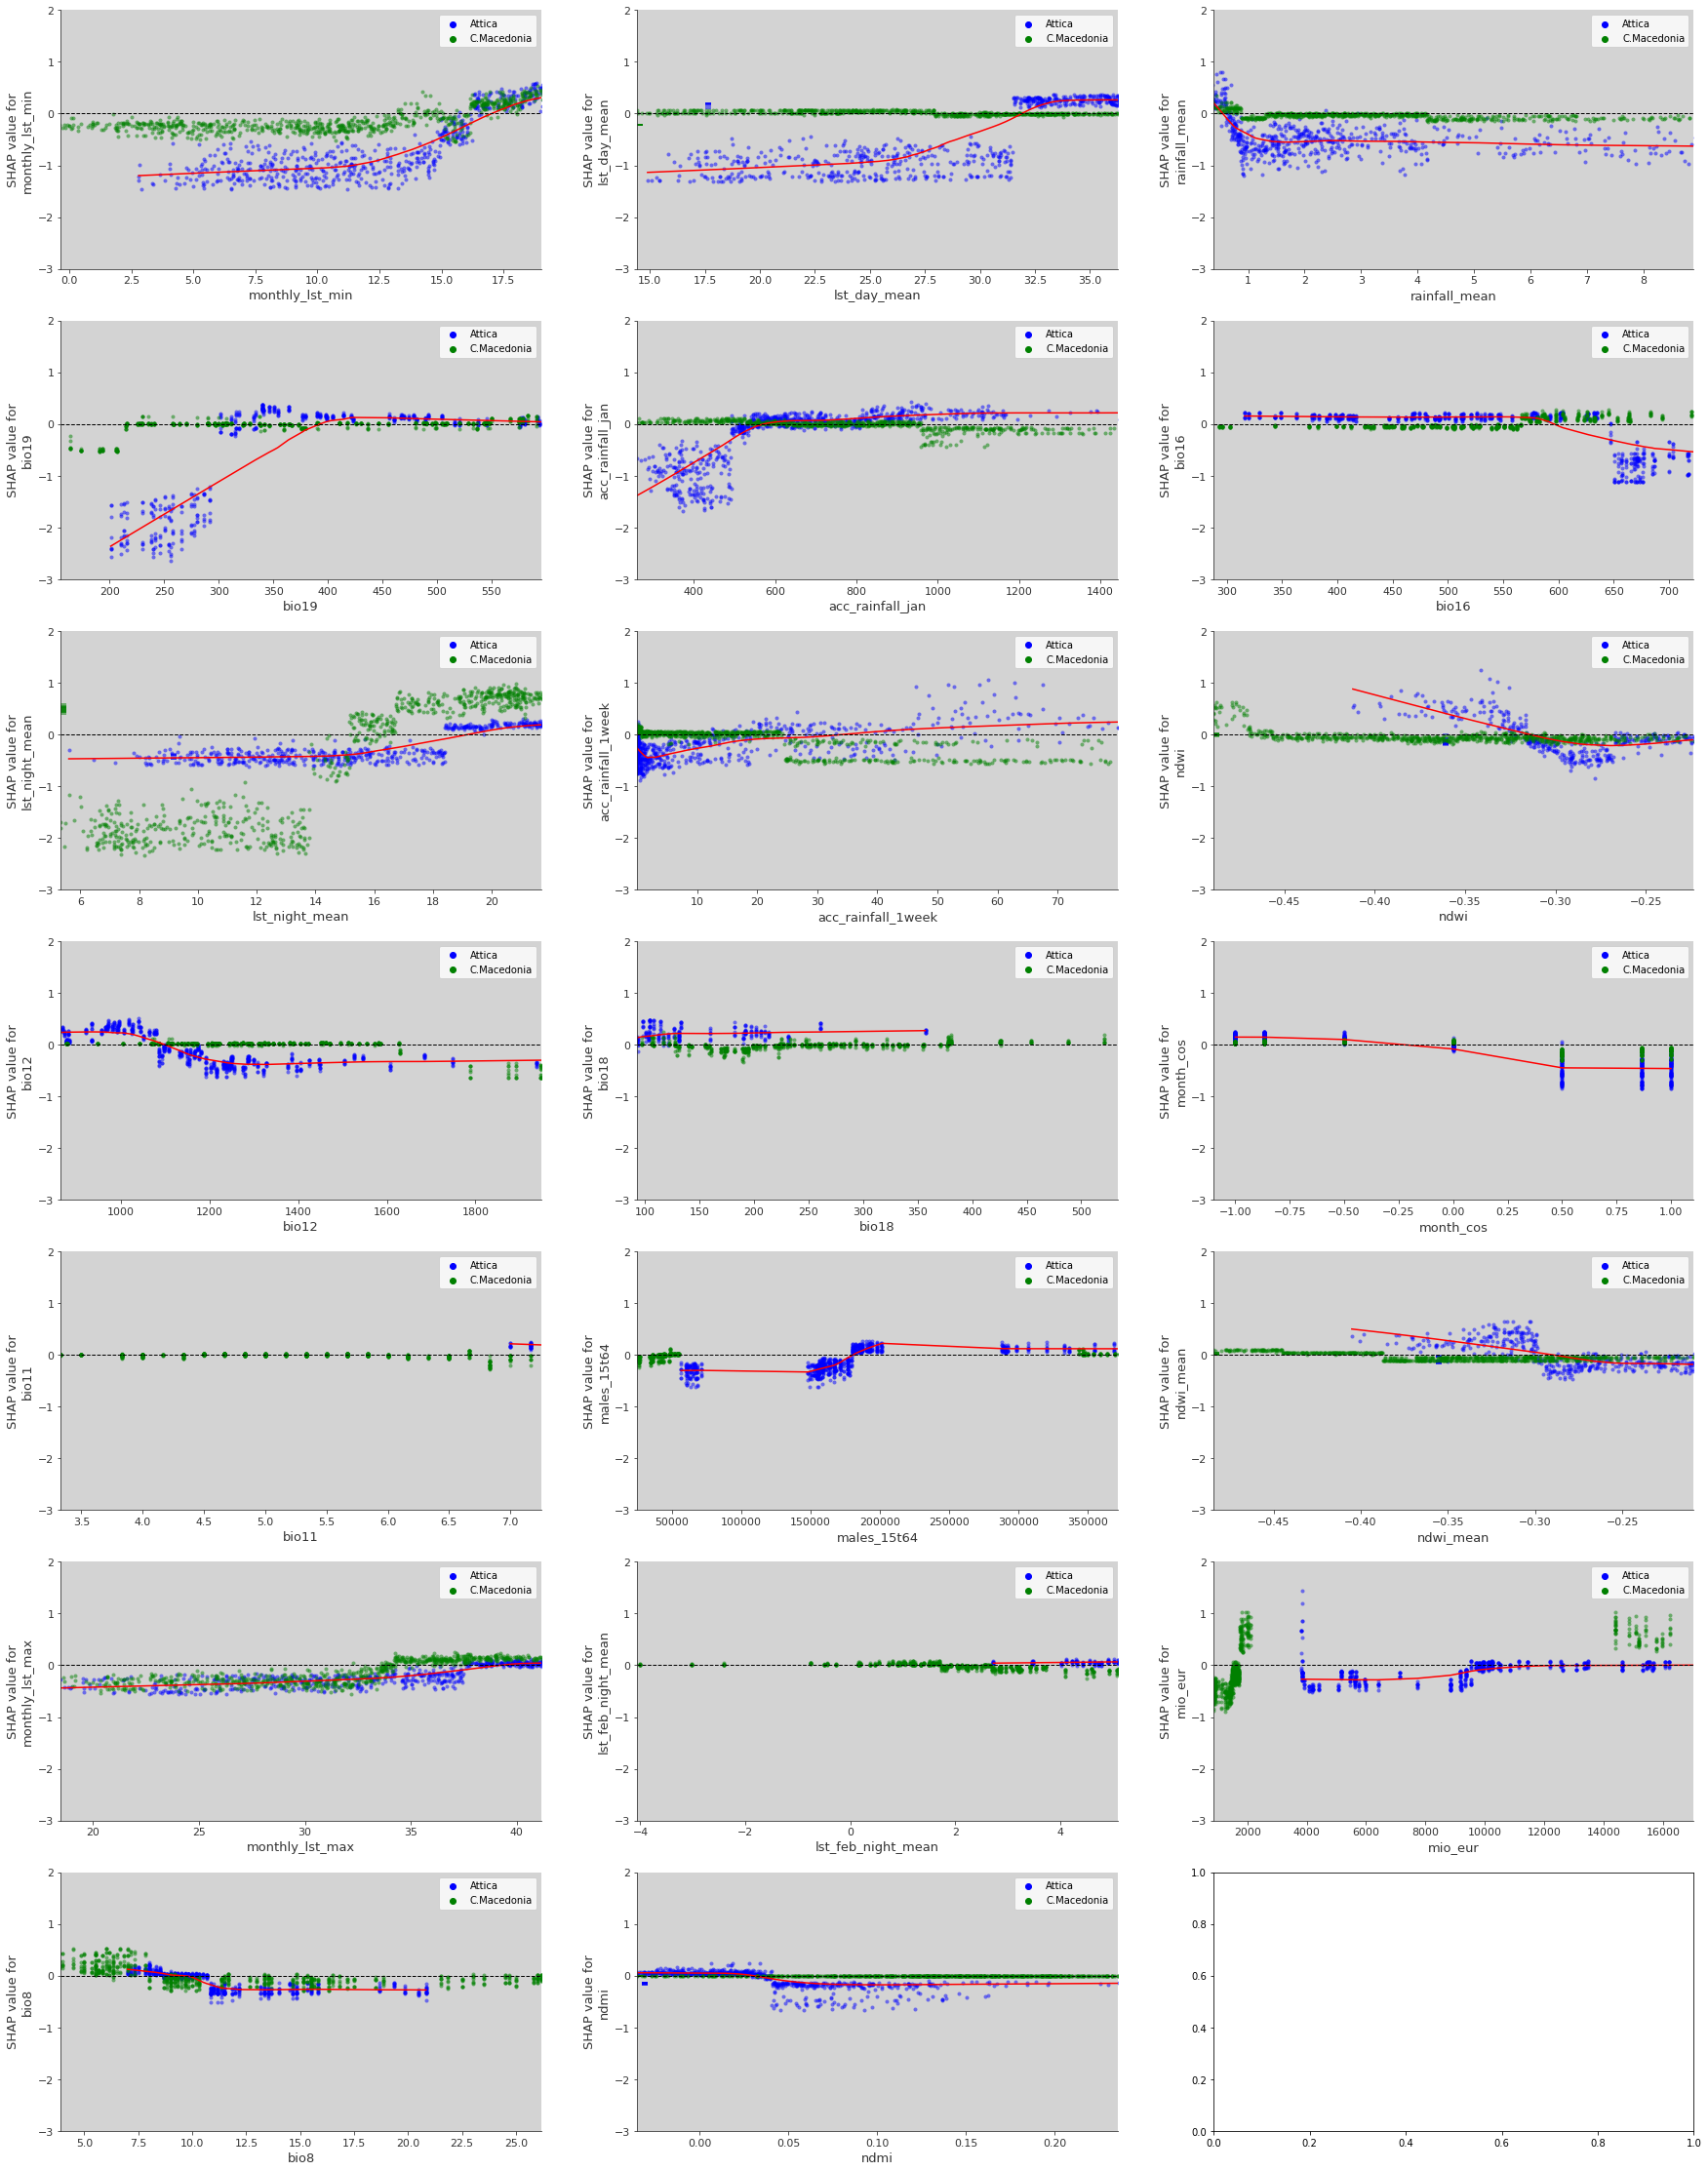

In [29]:
num_plots = 20

fig, axes = plt.subplots(7, 3, figsize=(30, 40))  # Adjust figsize as needed

i = 0

for ft in sorted_mean_abs_values_idx_attica[:num_plots]:
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    ax.set_facecolor('lightgrey')
    feature = ft
    data = data_at
    feature_names = data.columns

    shap_values_at = shap_values_df_attica
    shap_values_cm = shap_values_df_macedonia
    shap_values_em = shap_values_df_thrace
    shap_values_th = shap_values_df_thessaly

    idx = np.where(data_at.columns==feature)[0][0]
    x = data_at.iloc[:,idx]
    y_sv = shap_values_at[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it, frac=lowess_frac)
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)

    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_at, features=data_at, feature_names=feature_names, interaction_index=None, 
                         color='blue', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='Attica', color='blue')

    shap.dependence_plot(ind=feature, shap_values=shap_values_cm, features=data_cm, feature_names=feature_names, interaction_index=None, 
                         color='green', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='C.Macedonia', color='green')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_em, features=data_em, feature_names=feature_names, interaction_index=None, 
    #                      color='orange', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thrace', color='orange')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_th, features=data_th, feature_names=feature_names, interaction_index=None, 
    #                      color='fuchsia', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thessaly', color='fuchsia')
    
    ax.legend()
    
    i = i+1

plt.show()

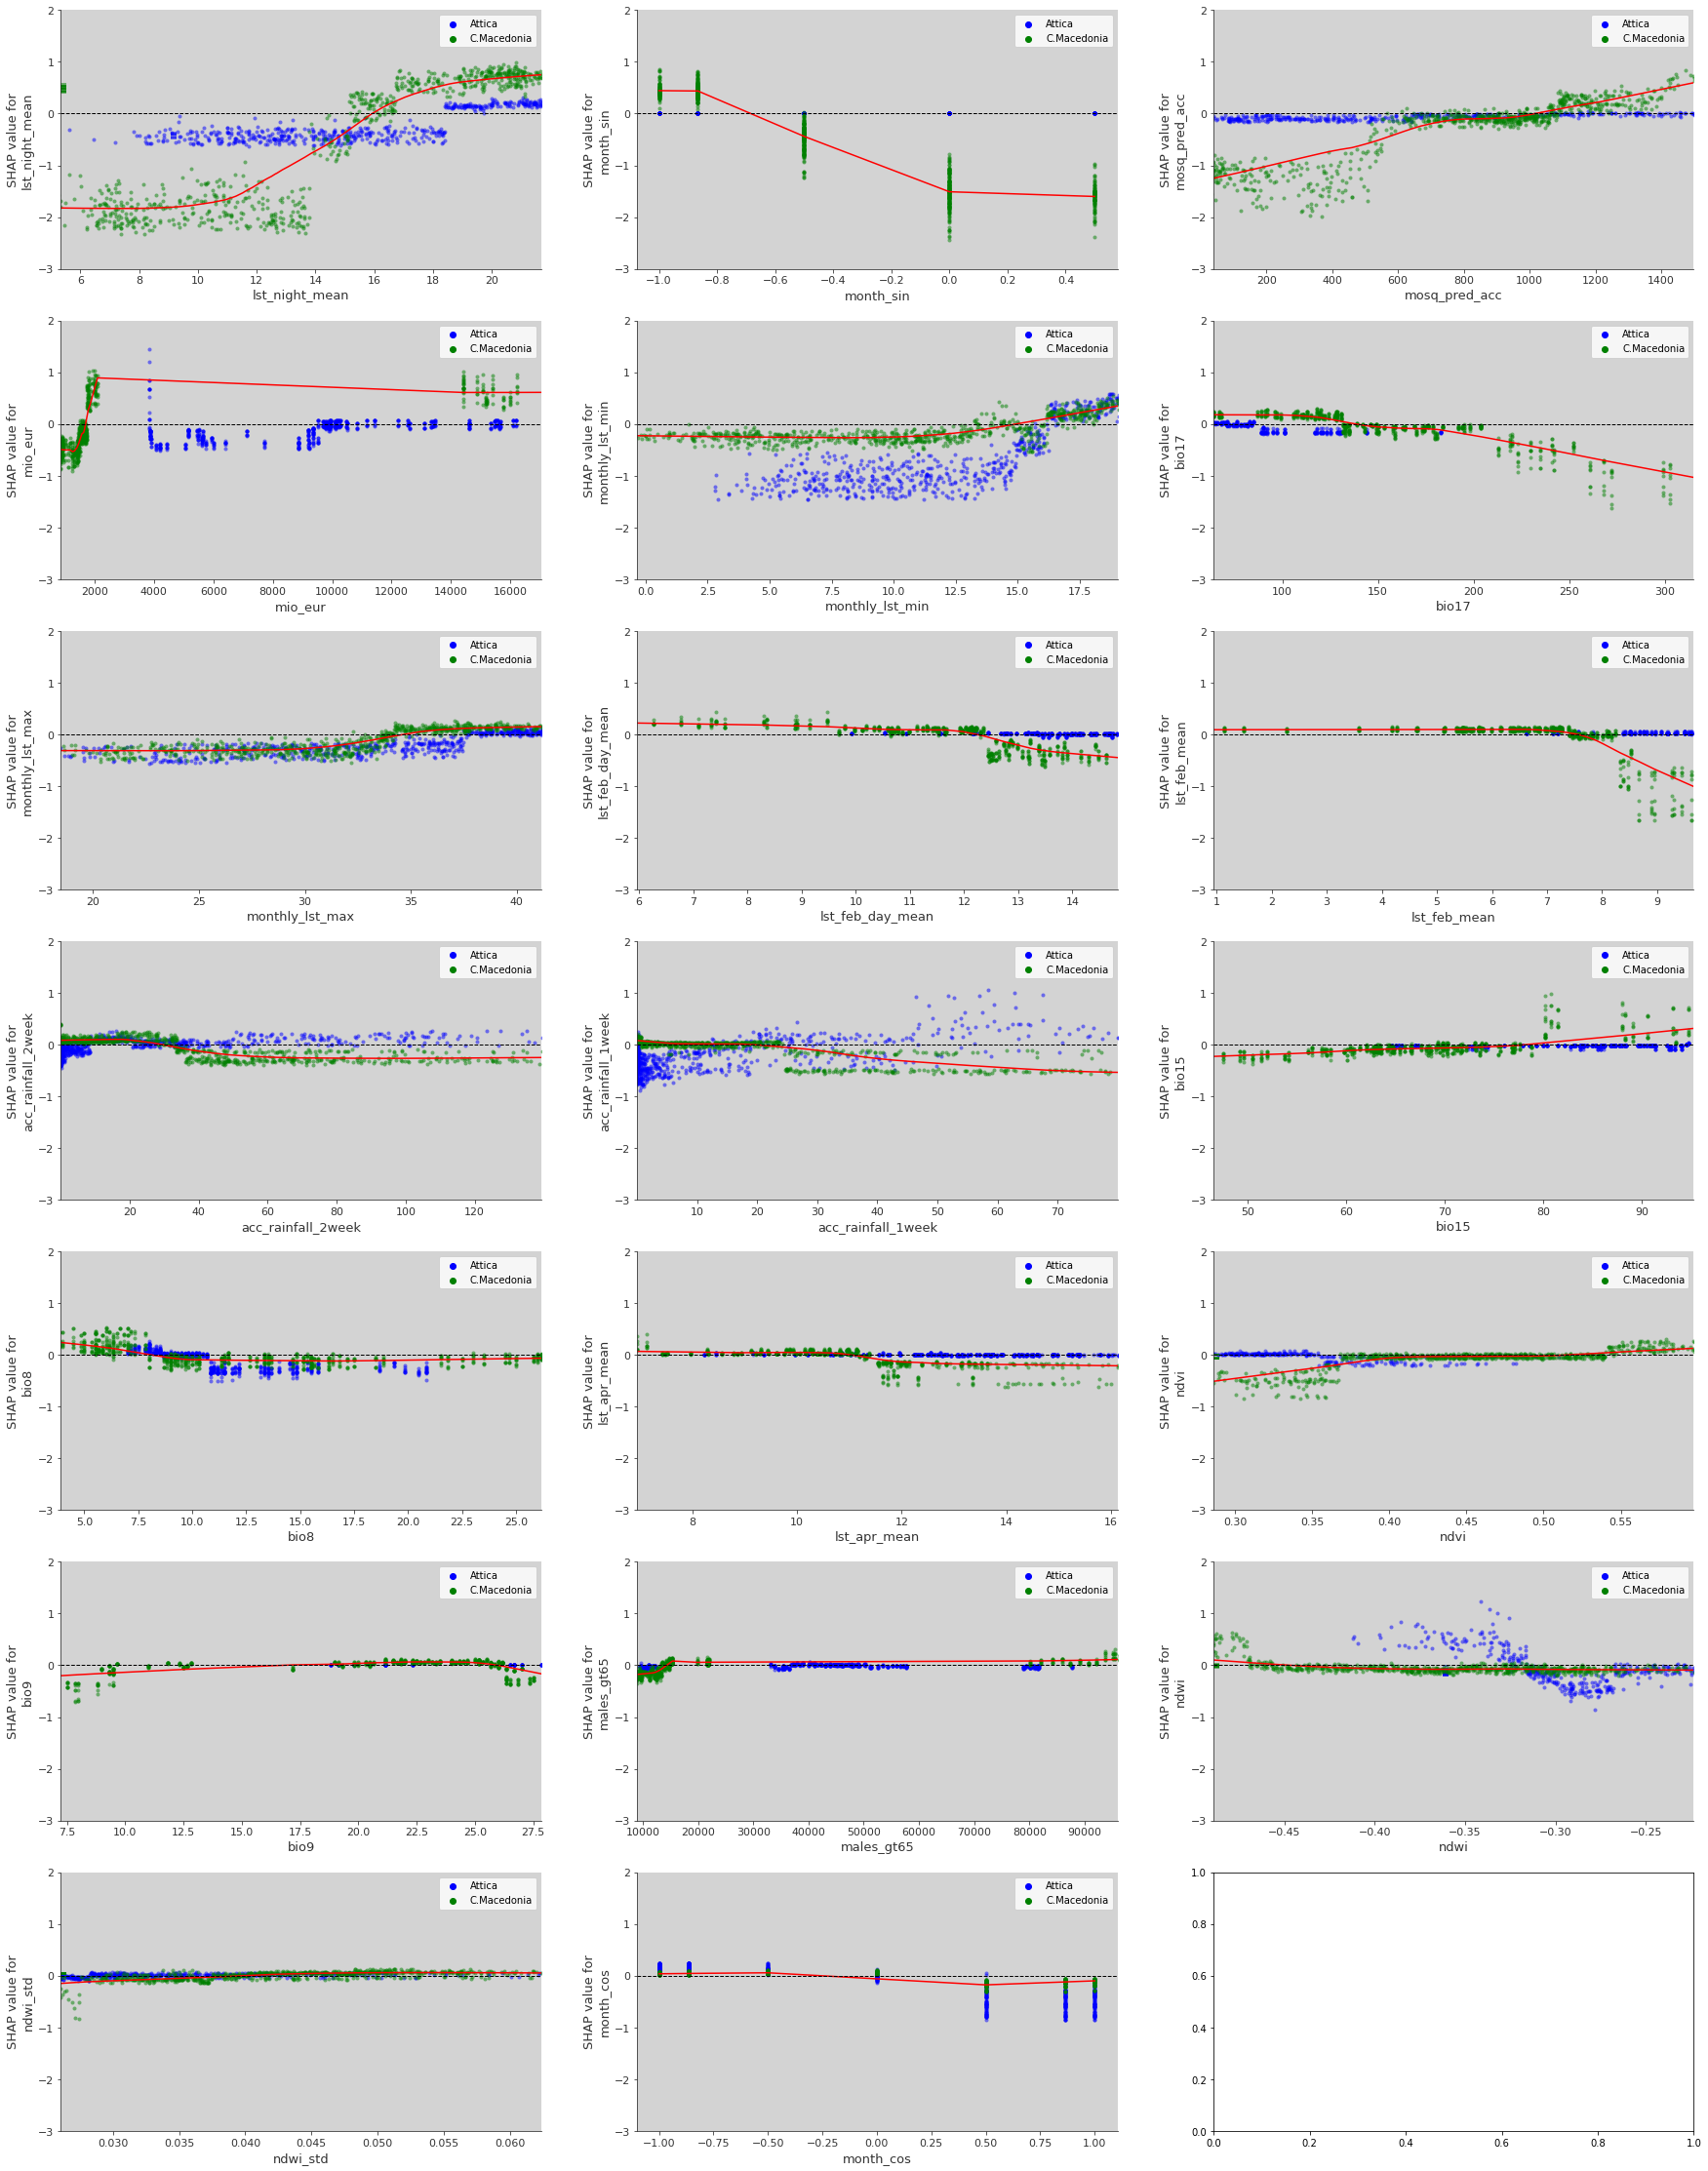

In [31]:
num_plots = 20

fig, axes = plt.subplots(7, 3, figsize=(30, 40))  # Adjust figsize as needed

i = 0

for ft in sorted_mean_abs_values_idx_macedonia[:num_plots]:
    row = i // 3
    col = i % 3
    
    ax = axes[row, col]
    ax.set_facecolor('lightgrey')
    feature = ft
    data = data_cm
    feature_names = data.columns

    shap_values_at = shap_values_df_attica
    shap_values_cm = shap_values_df_macedonia
    shap_values_em = shap_values_df_thrace
    shap_values_th = shap_values_df_thessaly

    idx = np.where(data.columns==feature)[0][0]
    x = data.iloc[:,idx]
    y_sv = shap_values_cm[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it, frac=lowess_frac)
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)

    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_at, features=data_at, feature_names=feature_names, interaction_index=None, 
                         color='blue', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='Attica', color='blue')

    shap.dependence_plot(ind=feature, shap_values=shap_values_cm, features=data_cm, feature_names=feature_names, interaction_index=None, 
                         color='green', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='C.Macedonia', color='green')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_em, features=data_em, feature_names=feature_names, interaction_index=None, 
    #                      color='orange', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thrace', color='orange')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_th, features=data_th, feature_names=feature_names, interaction_index=None, 
    #                      color='fuchsia', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thessaly', color='fuchsia')
    
    ax.legend()
    
    i = i+1

plt.show()

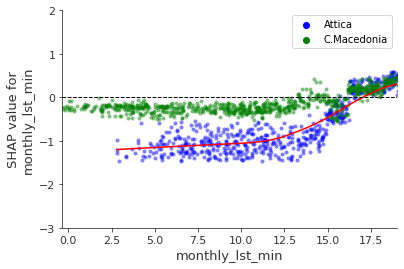

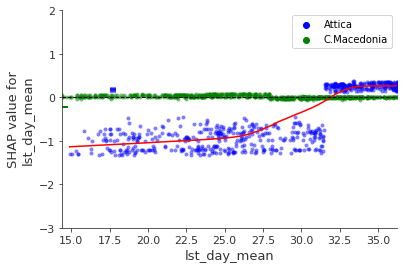

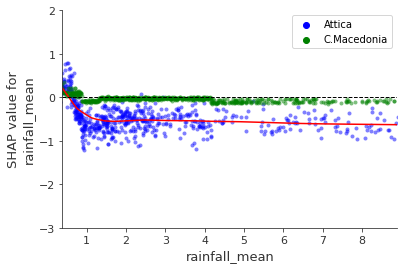

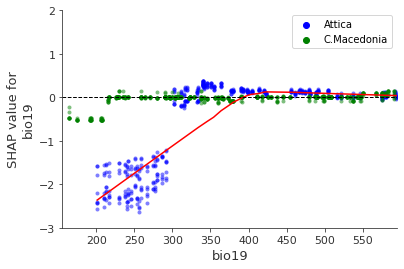

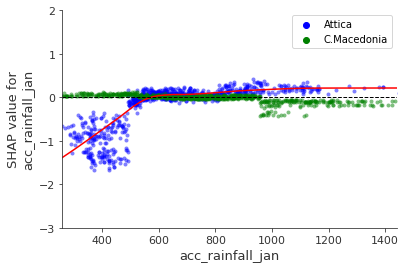

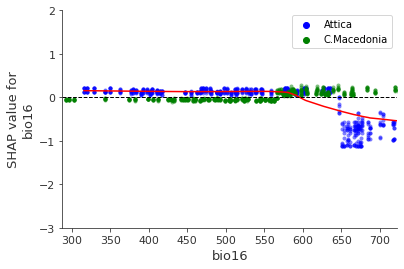

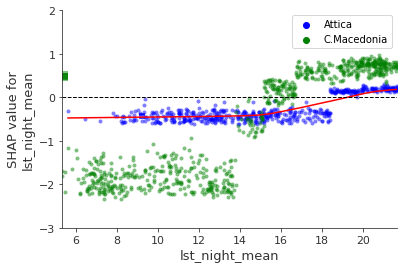

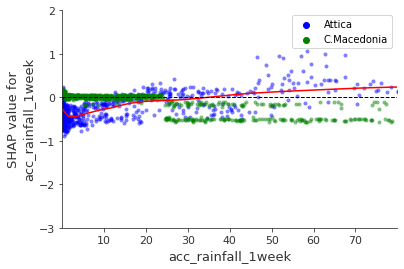

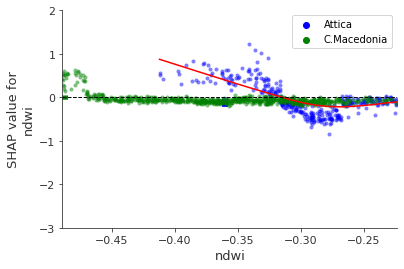

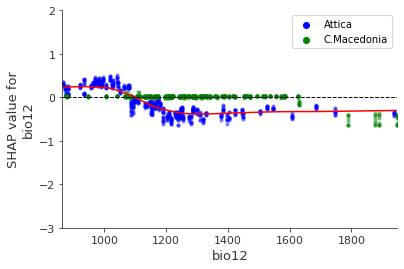

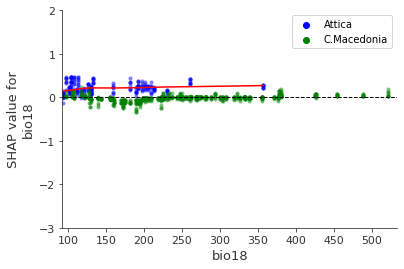

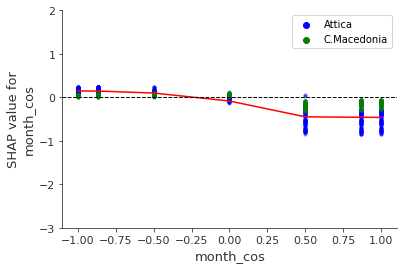

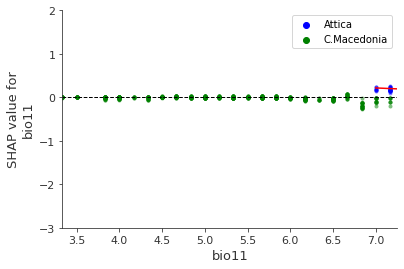

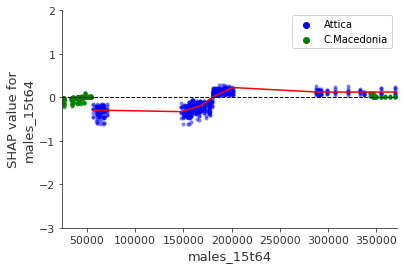

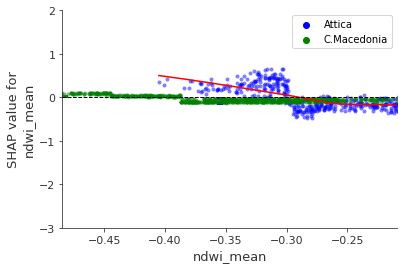

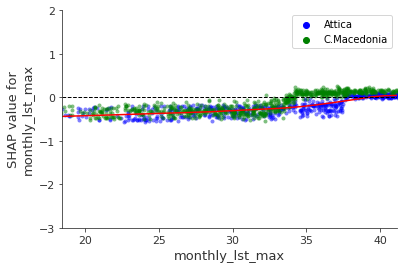

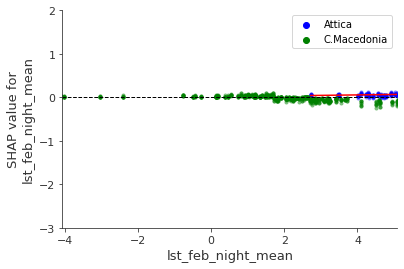

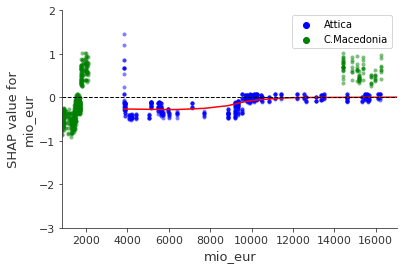

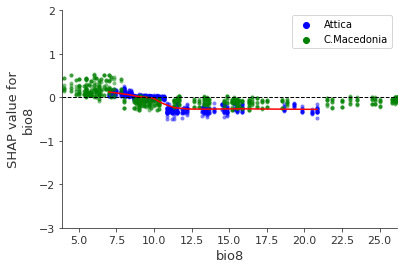

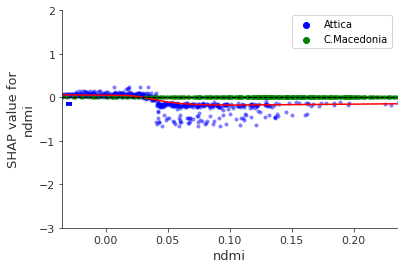

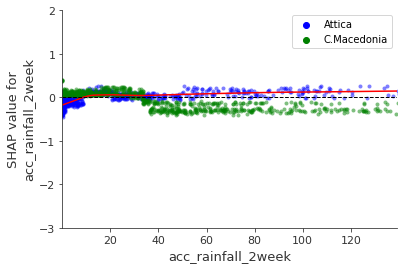

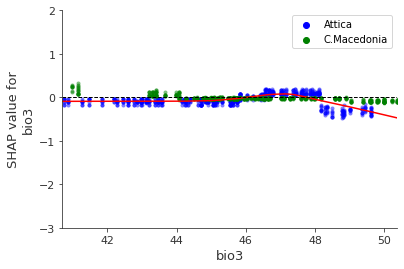

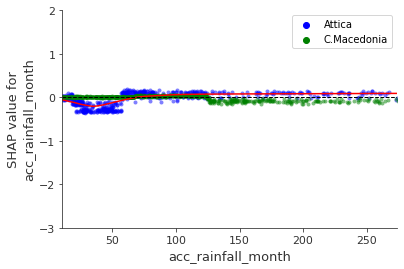

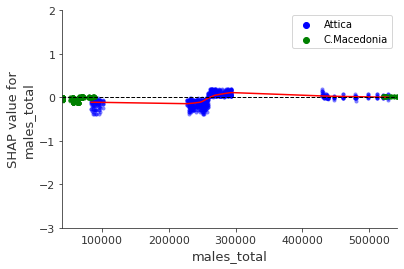

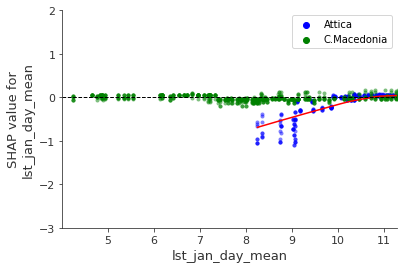

In [28]:
for ft in sorted_mean_abs_values_idx_attica[:25]:
    feature = ft
    data = data_at
    feature_names = data.columns

    shap_values_at = shap_values_df_attica
    shap_values_cm = shap_values_df_macedonia
    shap_values_em = shap_values_df_thrace
    shap_values_th = shap_values_df_thessaly
    
    idx = np.where(data.columns==feature)[0][0]
    x = data.iloc[:,idx]
    y_sv = shap_values_at[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it, frac=lowess_frac)

    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values_at, features=data_at, feature_names=feature_names, interaction_index=None, 
                         color='blue', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='Attica', color='blue')

    shap.dependence_plot(ind=feature, shap_values=shap_values_cm, features=data_cm, feature_names=feature_names, interaction_index=None, 
                         color='green', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    ax.scatter([], [], label='C.Macedonia', color='green')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_em, features=data_em, feature_names=feature_names, interaction_index=None, 
    #                      color='orange', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thrace', color='orange')
    
    # shap.dependence_plot(ind=feature, shap_values=shap_values_th, features=data_th, feature_names=feature_names, interaction_index=None, 
    #                      color='fuchsia', xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax=ax, show = False)
    # ax.scatter([], [], label='Thessaly', color='fuchsia')
    
    ax.legend()